# DAY 1 · ESS 배터리 수명 예측 — EDA 기반 모델 설계 전략
**울산캠퍼스 2반 · 손민재** · 데이터: MIT-Stanford (Severson et al., *Nature Energy* 2019) · Batch 1 + 2 + 3

각 질문은 **① 목적 → ② 무엇을 했나(코드) → ③ 결과 · 해석 → ④ 시사점 → 모델링** 순서입니다.

| 섹션 | 내용 |
|---|---|
| 0 | 환경 설정 · 데이터 로딩 |
| 1 | INPUT: Target 정의 검증 · 셀 선별 |
| 2 | 전처리 (EOL 미도달 · 스파이크 · 결측 · ΔQ 강건성) |
| 3 | 피처 테이블 생성 |
| Q1–Q5 | Notion · 스크래치 노트북의 5개 질문 |
| 4 | 종합: 배치 간 분포 이동 · 회귀 선택 |
| 5 | Feature Engineering (피처 선정 S1–S5) |
| 6 | 모델 설계 전략 요약 |


## 0. 환경 설정

In [1]:
# !pip install h5py scipy scikit-learn matplotlib pandas numpy
import os, re, pickle, warnings
import numpy as np, pandas as pd, h5py
import matplotlib.pyplot as plt, matplotlib.cm as cm, matplotlib.colors as mc
from matplotlib.patches import Patch
from scipy import stats
from sklearn.linear_model import LinearRegression
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.family': 'Apple SD Gothic Neo', 'axes.unicode_minus': False, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .25})
pd.set_option('display.width', 200, 'display.max_columns', 30)

ROOT = os.getcwd() if os.path.isdir(os.path.join(os.getcwd(), 'data')) else os.path.expanduser('~/Downloads/miniproject')   # 프로젝트 폴더
DATA_DIR  = os.path.join(ROOT, 'data', 'archive')   # .mat 파일 위치
CACHE_DIR = os.path.join(ROOT, 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)
FILES = {'B1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
         'B2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
         'B3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat'}
NOMINAL, EOL = 1.1, 0.88            # 공칭 용량(Ah), EOL = 80% SOH
BATCHES = ['B1', 'B2', 'B3']
COL = {'B1': '#2563eb', 'B2': '#f59e0b', 'B3': '#16a34a'}
rng = np.random.default_rng(0)
for f in FILES.values():
    print(f'{f:60s} {os.path.getsize(os.path.join(DATA_DIR, f)) / 1024**3:.1f} GB')

2017-05-12_batchdata_updated_struct_errorcorrect.mat         2.8 GB
2018-02-20_batchdata_updated_struct_errorcorrect.mat         1.9 GB
2018-04-12_batchdata_updated_struct_errorcorrect.mat         3.0 GB


### 0-1. 데이터 로딩 — 필요한 필드만 h5py로 추출
- 스크래치는 `mat73.loadmat()`으로 파일 전체(2~3GB)를 메모리에 올립니다. 여기서는 `h5py`로 **셀별 요약(summary), 수명, 충전방식, 초기 150 cycle의 `Qdlin`만** 읽어 캐시합니다(약 90MB).
- 스크래치 Hint대로 ΔQ(V)는 `cycles[n]['Qdlin']`으로 계산합니다.

In [2]:
NQ = 150   # Qdlin 보관 사이클 수

def _txt(f, ref):
    a = np.array(f[ref][()]).flatten()
    if a.dtype.kind not in 'iu' or a.size == 0 or a.max() > 0x10FFFF:
        return ''
    return ''.join(chr(int(c)) for c in a)

def extract(tag):
    with h5py.File(os.path.join(DATA_DIR, FILES[tag]), 'r') as f:
        b = f['batch']; vdlin = np.array(f[b['Vdlin'][0, 0]][()]).flatten(); cells = []
        for i in range(b['summary'].shape[0]):
            s = f[b['summary'][i, 0]]; cyc = f[b['cycles'][i, 0]]; nc = cyc['Qdlin'].shape[0]
            qd = [np.array(f[cyc['Qdlin'][j, 0]][()]).flatten() for j in range(min(NQ, nc))]
            qd = [a if a.size == vdlin.size else np.full(vdlin.size, np.nan) for a in qd]
            cells.append(dict(batch=tag, idx=i, name=f'{tag}c{i}', n_cycles=nc,
                              cycle_life=float(np.array(f[b['cycle_life'][i, 0]][()]).flatten()[0]),
                              policy=_txt(f, b['policy_readable'][i, 0]),
                              summary={k: np.array(s[k][()]).flatten() for k in s.keys()},
                              Qdlin=np.array(qd, dtype=np.float32)))
    return dict(vdlin=vdlin, cells=cells)

cells, vdlin = [], None
for tag in BATCHES:
    p = os.path.join(CACHE_DIR, f'{tag}.pkl')
    if not os.path.exists(p):
        pickle.dump(extract(tag), open(p, 'wb'))
    d = pickle.load(open(p, 'rb')); vdlin = d['vdlin']; cells += d['cells']
byname = {c['name']: c for c in cells}
print({t: sum(c['batch'] == t for c in cells) for t in BATCHES}, '셀 /', 'Vdlin', vdlin.shape, f'{vdlin.min()}~{vdlin.max()}V')
print('cycle 번호 시작값:', {t: int(next(c for c in cells if c['batch'] == t)['summary']['cycle'][0]) for t in BATCHES},
      '| B1 cycle1 QD =', byname['B1c5']['summary']['QDischarge'][0], '(더미)')

{'B1': 46, 'B2': 47, 'B3': 46} 셀 / Vdlin (1000,) 2.0~3.5V
cycle 번호 시작값: {'B1': 1, 'B2': 1, 'B3': 1} | B1 cycle1 QD = 0.0 (더미)


## 1. INPUT — Target 정의 검증과 셀 선별
**① 목적** Target(`cycle_life`)이 Notion 정의 **“EOL(80% SOH 도달)까지의 총 사이클 수”** 와 맞는지 확인하고, 맞지 않는 Target 값은 걸러낸다. **Target Data = `cycle_life`**.
- SOH = 처음 대비 현재 용량. 공칭 1.1Ah × 80% = **0.88Ah** 아래로 떨어지는 시점이 EOL.

**② 무엇을 했나** 셀마다 마지막 방전 용량(QD)을 확인 → `valid`(EOL 도달) / `censored`(EOL 미도달인데 cycle_life 기록) / `no_label`(NaN) 분류.

In [3]:
def parse_policy(p):
    m = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', p)
    return (float(m[1]), float(m[2]), float(m[3])) if m else (np.nan,) * 3

def status(c):
    if np.isnan(c['cycle_life']): return 'no_label'
    q = c['summary']['QDischarge']; q = q[q > 0.5]
    return 'valid' if q[-1] <= EOL + 0.005 else 'censored'

rows = []
for c in cells:
    c1, sw, c2 = parse_policy(c['policy']); q = c['summary']['QDischarge']; q = q[q > 0.5]
    rows.append(dict(cell=c['name'], batch=c['batch'], cycle_life=c['cycle_life'], policy=c['policy'], c1=c1, soc_sw=sw, c2=c2,
                     avg_c=(c1 * sw + c2 * (80 - sw)) / 80 if sw <= 80 else np.nan,
                     last_QD=round(float(q[-1]), 3), status=status(c)))
T = pd.DataFrame(rows).set_index('cell')
display(T.groupby(['batch', 'status']).size().unstack(fill_value=0))
# 검증: cycle_life = QD가 처음 0.88Ah 미만이 되는 사이클인가?
chk = []
for c in cells:
    if T.loc[c['name'], 'status'] != 'valid': continue
    q = c['summary']['QDischarge']; cyc = c['summary']['cycle']; below = (q < EOL) & (q > 0.5)
    chk.append(dict(batch=c['batch'], first_below=int(cyc[np.argmax(below)]) if below.any() else None,
                    cycle_life=int(c['cycle_life']), QD_at_end=round(float(q[q > 0.5][min(int(c['cycle_life']), (q > 0.5).sum()) - 1]), 3)))
chk = pd.DataFrame(chk)
print('B2: cycle_life == 첫 0.88Ah 미만 사이클 →', (chk[chk.batch == 'B2'].first_below == chk[chk.batch == 'B2'].cycle_life).sum(), '/', (chk.batch == 'B2').sum(), '셀 일치')
print('B1·B3: 측정 종료 시점 QD 범위', chk[chk.batch != 'B2'].QD_at_end.agg(['min', 'max']).tolist(), '→ EOL(0.88Ah) 도달 시점에 종료 ✔')
display(T[T.status != 'valid'][['cycle_life', 'policy', 'last_QD', 'status']])

status,censored,no_label,valid
batch,,,
B1,10,0,36
B2,0,8,39
B3,0,2,44


B2: cycle_life == 첫 0.88Ah 미만 사이클 → 39 / 39 셀 일치
B1·B3: 측정 종료 시점 QD 범위 [0.88, 0.883] → EOL(0.88Ah) 도달 시점에 종료 ✔


,cycle_life,policy,last_QD,status
cell,,,,
B1c0,1190.0,3.6C(80%)-3.6C,1.026,censored
B1c1,1179.0,3.6C(80%)-3.6C,1.038,censored
B1c2,1177.0,3.6C(80%)-3.6C,1.043,censored
B1c3,1226.0,4C(80%)-4C,0.971,censored
B1c4,1227.0,4C(80%)-4C,1.022,censored
B1c8,879.0,5.4C(40%)-3.6C,0.969,censored
B1c10,906.0,5.4C(50%)-3C,0.961,censored
B1c12,902.0,5.4C(50%)-3.6C,0.913,censored
B1c13,897.0,5.4C(50%)-3.6C,0.923,censored


### EOL 미도달 셀이란?
- EOL(수명 끝) = 용량이 처음의 80%인 **0.88Ah** 아래로 떨어지는 순간. 그때까지의 사이클 수가 Target(`cycle_life`).
- 일부 셀은 **배터리가 아직 살아 있는데 실험이 먼저 끝났고**, 측정을 멈춘 시점의 사이클 수가 `cycle_life`로 적혀 있다 → 진짜 수명보다 짧은 **틀린 Target 값**.
- 원논문은 B1c0–4를 다른 파일에 이어 측정한 데이터로 수명을 복원했지만, Kaggle 파일엔 그 데이터가 없어 복원 불가 → 제외.

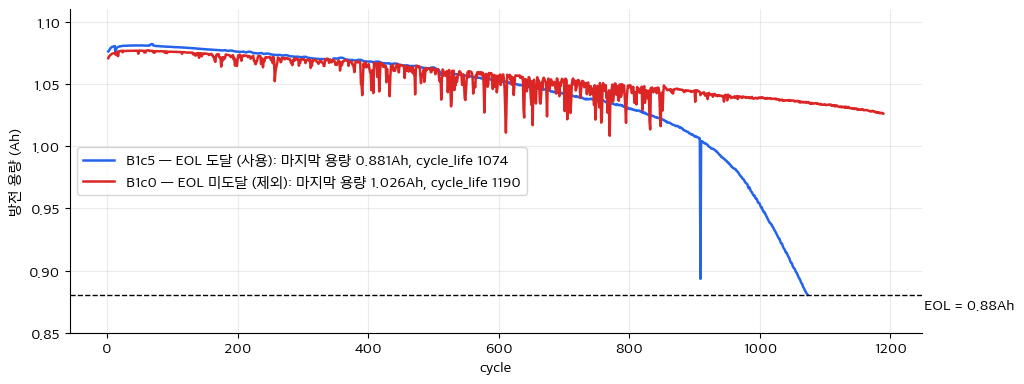

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
for n, col, lab in [('B1c5', '#2563eb', 'B1c5 — EOL 도달 (사용)'), ('B1c0', '#dc2626', 'B1c0 — EOL 미도달 (제외)')]:
    q = byname[n]['summary']['QDischarge']; cyc = byname[n]['summary']['cycle']; m = (q > 0.5) & (q < 1.3)
    ax.plot(cyc[m], q[m], color=col, lw=1.8, label=f"{lab}: 마지막 용량 {q[m][-1]:.3f}Ah, cycle_life {int(byname[n]['cycle_life'])}")
ax.axhline(EOL, color='k', ls='--', lw=1); ax.text(1390, EOL - .012, 'EOL = 0.88Ah', ha='right')
ax.set_xlabel('cycle'); ax.set_ylabel('방전 용량 (Ah)'); ax.set_ylim(.85, 1.11); ax.legend(loc='center left'); plt.show()

**스크래치와 비교 — 소수의 잘린 셀이 끌어낸 온도 상관**
스크래치처럼 B1 46셀 전체(EOL 미도달 10셀 포함)로 초기 100 cycle 평균과 수명의 Pearson 상관을 구하면 온도 상관이 강하게 나오지만, 미도달 셀을 빼면 약해진다. 어떤 셀이 상관을 끌어당기는지도 확인한다.

In [5]:
def scratch_style(cs):
    out = {}
    for c in cs:
        s = c['summary']
        out[c['name']] = {k: np.mean(s[src][:100]) for k, src in [('mean_chargetime', 'chargetime'), ('mean_Tavg', 'Tavg'), ('mean_Tmax', 'Tmax'), ('mean_QD', 'QDischarge'), ('mean_IR', 'IR')]}
    return pd.DataFrame(out).T.join(T[['cycle_life', 'status']])
b1 = scratch_style([c for c in cells if c['batch'] == 'B1'])
cmp = pd.DataFrame({'스크래치(46셀)': b1.drop(columns='status').corr()['cycle_life'].drop('cycle_life'),
                    'EOL 미도달 제외(36셀)': b1[b1.status == 'valid'].drop(columns='status').corr()['cycle_life'].drop('cycle_life')}).round(2)
display(cmp)

b1['Tavg_rank'] = b1.mean_Tavg.rank().astype(int)   # 1 = 가장 시원
print('[잘린 셀의 온도 순위(46셀 중) · 기록된 수명]')
display(b1[b1.status == 'censored'].sort_values('Tavg_rank')[['Tavg_rank', 'mean_Tavg', 'cycle_life']].round(2))
ok = b1[b1.status == 'valid']
print(f"정상 셀 수명 상위 10개 평균 온도 {ok.nlargest(10, 'cycle_life').mean_Tavg.mean():.1f}°C / 하위 10개 {ok.nsmallest(10, 'cycle_life').mean_Tavg.mean():.1f}°C")

,스크래치(46셀),EOL 미도달 제외(36셀)
mean_chargetime,0.58,0.49
mean_Tavg,-0.48,-0.17
mean_Tmax,-0.40,-0.16
mean_QD,0.19,0.21
mean_IR,0.18,0.24


[잘린 셀의 온도 순위(46셀 중) · 기록된 수명]


,Tavg_rank,mean_Tavg,cycle_life
B1c3,1,29.64,1226.0
B1c1,4,31.02,1179.0
B1c4,5,31.13,1227.0
B1c2,6,31.16,1177.0
B1c0,7,31.29,1190.0
B1c8,12,31.76,879.0
B1c13,14,31.77,897.0
B1c22,24,32.52,891.0
B1c10,34,32.88,906.0
B1c12,37,33.12,902.0


정상 셀 수명 상위 10개 평균 온도 32.0°C / 하위 10개 32.5°C


**③ 결과** 원본 139셀 → **119셀 사용**(B1 36 · B2 39 · B3 44). cycle_life가 0.88Ah 기준임을 확인(B2는 첫 0.88Ah 미만 사이클과 39셀 일치, B1·B3는 0.880~0.883Ah에서 측정 종료). 스크래치 방식의 온도 상관 −0.48은 천천히 충전해 가장 시원하고(1·4~7위) 가장 오래 사는 잘린 셀 5개(B1c0–4)가 끌어낸 값으로, Target 값이 확실한 36셀만 보면 −0.17. 정상 셀 수명 상위·하위 10개의 평균 온도 차도 0.5°C(32.0 대 32.5)뿐.

**④ 시사점** 실제보다 짧게 기록된 Target 값(censored)은 쓸 수 없어 제외. 온도는 수명을 정하는 신호라기보다 충전 속도를 따라 움직인 결과로 보인다.

## 2. 전처리
**① 목적** 측정 오류가 초기 100 cycle 피처를 오염시키지 않도록 한다.

**② 무엇을 했나**
1. QD 2단계 정제: (1) 물리 범위 0.5~1.3Ah 밖 → NaN (cycle 1 더미 포함) (2) rolling median(11)에서 ±0.02Ah 이상 튀는 단발 스파이크 → NaN → 선형 보간
2. IR ≤ 0 → 결측, 시간 통계는 평균 대신 중앙값(충전시간 튐 대응)
3. ΔQ(V) 비교 사이클 선택(100−10)이 결론을 바꾸는지 대안 4개로 확인

,cycle1 더미(셀),범위 밖(건),스파이크(건),IR 결측(셀),충전시간>20분(셀)
batch,,,,,
B1,36,1,1,0,3
B2,0,0,8,6,10
B3,0,0,2,0,0


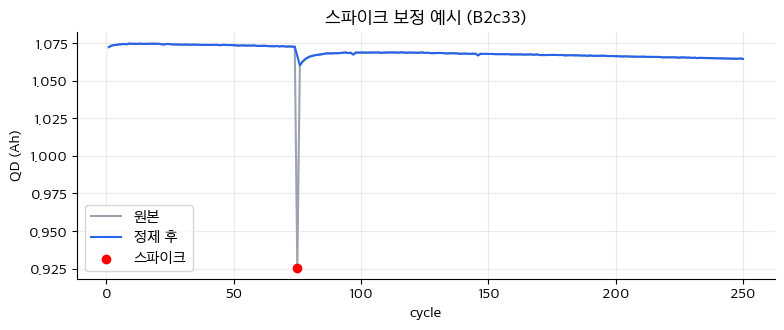

In [6]:
SPIKE_TOL = 0.02   # Ah: 정상 사이클 간 변동(~0.001-0.003)의 약 10배

def clean_qd(c, return_mask=False):
    s = c['summary']; cyc = s['cycle'].astype(int); q = s['QDischarge'].astype(float).copy()
    bad = (q < 0.5) | (q > 1.3); q[bad] = np.nan
    rm = pd.Series(q).rolling(11, center=True, min_periods=3).median().values
    spike = np.abs(q - rm) > SPIKE_TOL; q[spike] = np.nan
    q = pd.Series(q).interpolate(limit_direction='both').values
    return (cyc, q, bad, spike) if return_mask else (cyc, q)

V = T[T.status == 'valid'].copy()
log = []
for n in V.index:
    c = byname[n]; s = c['summary']; cyc, q, bad, spike = clean_qd(c, True); w = cyc <= c['cycle_life']
    log.append(dict(batch=c['batch'], dummy=int(s['QDischarge'][0] < .5), out_range=int((bad & w & (cyc > 1)).sum()),
                    spike=int((spike & w).sum()), ir_missing=int(np.all(s['IR'][1:100] <= 0)), ct_over20=int((s['chargetime'][1:100] > 20).any())))
display(pd.DataFrame(log).groupby('batch').sum().rename(columns={'dummy': 'cycle1 더미(셀)', 'out_range': '범위 밖(건)', 'spike': '스파이크(건)', 'ir_missing': 'IR 결측(셀)', 'ct_over20': '충전시간>20분(셀)'}))

c = byname['B2c33']; cyc, q, bad, spike = clean_qd(c, True); m = cyc <= 250
plt.figure(figsize=(9, 3.2)); plt.plot(cyc[m], c['summary']['QDischarge'][m], color='#9ca3af', label='원본')
plt.plot(cyc[m], q[m], color='#2563eb', label='정제 후'); plt.scatter(cyc[m & spike], c['summary']['QDischarge'][m & spike], color='red', zorder=5, label='스파이크')
plt.title('스파이크 보정 예시 (B2c33)'); plt.xlabel('cycle'); plt.ylabel('QD (Ah)'); plt.legend(); plt.show()

**셀 선별 결과** — 총 139셀 중 **20셀 제외 → 119셀 사용** · B1 46 → **36** (EOL 미도달 10) · B2 47 → **39** (Target 값 없음 8) · B3 46 → **44** (Target 값 없음 2) · extra 파일 2셀은 별도 제외

**스파이크 보정 예시 (위 그림)** — B2c33의 용량이 cycle 75 부근에서 한 번만 0.925Ah로 떨어졌다가 바로 1.06Ah대로 돌아온다. 한 사이클에 14% 줄었다 회복하는 건 실제 열화가 아니라 측정 오류라, 앞뒤 11개 중앙값과 0.02Ah 이상 차이 나는 값(빨간 점)을 앞뒤 값으로 메웠다(파란선).

In [7]:
print(T.groupby('batch').status.value_counts().unstack(fill_value=0).assign(전체=lambda d: d.sum(1)).rename(columns={'valid': '사용', 'censored': 'EOL 미도달 제외', 'no_label': 'Target 값 없음 제외'}))
print('총', len(T), '셀 중', (T.status != 'valid').sum(), '셀 제외 →', (T.status == 'valid').sum(), '셀 사용')

status  EOL 미도달 제외  Target 값 없음 제외  사용  전체
batch                                     
B1              10               0  36  46
B2               0               8  39  47
B3               0               2  44  46
총 139 셀 중 20 셀 제외 → 119 셀 사용


In [8]:
def delta_q(c, hi=100, lo=10):        # cycle 번호(1-based) → index = cycle-1  (= cycles[99] - cycles[9])
    return c['Qdlin'][hi - 1].astype(float) - c['Qdlin'][lo - 1].astype(float)

def dqv(c, hi, lo):
    if isinstance(hi, tuple):
        d = np.nanmedian(c['Qdlin'][hi[0]-1:hi[1]], 0) - np.nanmedian(c['Qdlin'][lo[0]-1:lo[1]], 0)
    else:
        d = c['Qdlin'][hi - 1] - c['Qdlin'][lo - 1]
    d = d[np.isfinite(d)].astype(float); return np.log10(np.var(d))

V['log_life'] = np.log10(V.cycle_life)
R = pd.DataFrame({k: [dqv(byname[n], *hl) for n in V.index] for k, hl in
                  {'100-10(기준)': (100, 10), '99-9': (99, 9), '101-11': (101, 11), '100-20': (100, 20), '중앙값 98~102 - 8~12': ((98, 102), (8, 12))}.items()}, index=V.index)
b1m = V.batch == 'B1'
display(pd.DataFrame({'기준과 Spearman': R.corrwith(R['100-10(기준)'], method='spearman'),
                      'B1 log수명 ρ': R[b1m].corrwith(V.log_life[b1m], method='spearman')}).round(3))

,기준과 Spearman,B1 log수명 ρ
100-10(기준),1.000,-0.826
99-9,0.983,-0.821
101-11,0.987,-0.807
100-20,0.985,-0.799
중앙값 98~102 - 8~12,0.995,-0.820


**③ 결과** 셀 20개 제외 → 119셀 사용(B1 36 · B2 39 · B3 44). cycle 1 더미 36셀(B1), 범위 밖 1건, 스파이크 11건(B1 1 · B2 8 · B3 2), IR 결측 6셀(B2c41–46), 충전시간 튐 13셀. ΔQ 대안 4개는 기준과 상관 ≥ 0.98, B1 수명 상관 0.80~0.83.
**④ 시사점** 정제 후 피처를 사용. ΔQ는 cycle 100−10 유지(결론 불변).

## 3. 피처 테이블 생성 (초기 100 cycle 정보만)
- **ΔQ(V) 통계** (원논문 방식): log10 Var · |Min| · |Mean| · |Skew| · |Kurt|
- **초기 사이클 요약**: QD(cycle 2/100), QD 기울기(2~100), IR·온도·충전시간·충전용량(중앙값) 등
- **knee** (EDA 해석용, 사후 정보라 피처로 쓰지 않음): 두 직선 piecewise 회귀

In [9]:
def dq_feats(dq):
    d = dq[np.isfinite(dq)]
    return {'dq_var': np.log10(abs(np.var(d))), 'dq_min': np.log10(abs(d.min())), 'dq_mean': np.log10(abs(d.mean())),
            'dq_skew': np.log10(abs(stats.skew(d))), 'dq_kurt': np.log10(abs(stats.kurtosis(d)))}

def early_feats(c, n=100):
    s = c['summary']; cyc, qd = clean_qd(c); m = (cyc >= 2) & (cyc <= n)
    ir = np.where(s['IR'] > 0, s['IR'].astype(float), np.nan)
    return {'qd_2': qd[1], 'qd_100': qd[n - 1], 'qd_max_2_100': qd[m].max(), 'qd_slope_2_100': np.polyfit(cyc[m], qd[m], 1)[0],
            'qd_diff_100_2': qd[n - 1] - qd[1], 'ir_mean': np.nanmedian(ir[1:n]), 'ir_100_2': np.nanmedian(ir[n-10:n]) - np.nanmedian(ir[1:11]),
            'tavg_mean': np.nanmedian(s['Tavg'][1:n]), 'tmax_mean': np.nanmedian(s['Tmax'][1:n]), 'tmin_mean': np.nanmedian(s['Tmin'][1:n]),
            'ct_mean': np.nanmedian(s['chargetime'][1:n]), 'qc_mean': np.nanmedian(s['QCharge'][1:n])}

def knee_bw(x, y, min_seg=30):
    best = (np.inf, None)
    for k in range(min_seg, len(x) - min_seg, 5):
        p1, p2 = np.polyfit(x[:k], y[:k], 1), np.polyfit(x[k:], y[k:], 1)
        sse = ((np.polyval(p1, x[:k]) - y[:k])**2).sum() + ((np.polyval(p2, x[k:]) - y[k:])**2).sum()
        if sse < best[0]: best = (sse, (x[k], p1[0], p2[0]))
    return best[1]

F = {}
for n in V.index:
    c = byname[n]; r = {**dq_feats(delta_q(c)), **early_feats(c)}
    cyc, q = clean_qd(c); m = (cyc >= 10) & (cyc <= c['cycle_life'])
    k, s1, s2 = knee_bw(cyc[m].astype(float), q[m]); r.update(knee=k, s1=s1 * 1e4, s2=s2 * 1e4); F[n] = r
V = V.join(pd.DataFrame(F).T)
V['newstruct'] = V.policy.str.contains('newstructure').astype(int)
V['knee_frac'] = V.knee / V.cycle_life; V['ratio'] = V.s2 / V.s1
V['t80_min'] = 60 * (V.soc_sw / 100 / V.c1 + (80 - V.soc_sw) / 100 / V.c2)   # 0→80% 충전 소요(분, 설계값)
print(V.shape); display(V.head(3))

(119, 34)


,batch,cycle_life,policy,c1,soc_sw,c2,avg_c,last_QD,status,log_life,dq_var,dq_min,dq_mean,dq_skew,dq_kurt,...,qd_diff_100_2,ir_mean,ir_100_2,tavg_mean,tmax_mean,tmin_mean,ct_mean,qc_mean,knee,s1,s2,newstruct,knee_frac,ratio,t80_min
cell,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B1c5,B1,1074.0,4.4C(80%)-4.4C,4.4,80.0,4.4,4.4,0.881,valid,3.031004,-4.178878,-1.598966,-1.955699,-0.825795,0.089031,...,0.003653,0.016274,0.000035,30.819317,32.907345,29.130405,10.917415,1.080412,885.0,-0.702967,-7.106726,0,0.824022,10.109618,10.909091
B1c6,B1,636.0,4.8C(80%)-4.8C,4.8,80.0,4.8,4.8,0.880,valid,2.803457,-3.768878,-1.421521,-1.796830,-0.389408,0.092745,...,0.003407,0.016665,-0.000147,32.227697,35.802235,29.695097,10.008315,1.080791,515.0,-1.120310,-11.616726,0,0.809748,10.369207,10.000000
B1c7,B1,870.0,4.8C(80%)-4.8C,4.8,80.0,4.8,4.8,0.881,valid,2.939519,-3.813486,-1.417558,-1.778697,-0.477013,0.049426,...,0.001898,0.016209,0.000087,31.948693,35.308605,29.542273,10.009005,1.096831,645.0,-0.779311,-7.160025,0,0.741379,9.187632,10.000000


## Q1. Cycle Life 분포는 어떻게 생겼는가?
**① 목적** 타깃의 형태(범위·왜도)와 배치 간 차이를 알아야 타깃 변환, 외삽 필요성, 회귀/분류 선택을 정할 수 있다.

**② 무엇을 했나**
- **[Histogram]** 배치별 히스토그램 + 박스플롯
- **[장/단수명 비율]** >1,000 / <500 셀 비율
- **[이상치 · 왜 짧은가]** IQR 1.5배 규칙 → 해당 셀의 충전방식·셀 구조 추적
- 타깃 log 변환 전/후, 핵심 피처(log Var ΔQ) 배치별 분포 + KS 검정

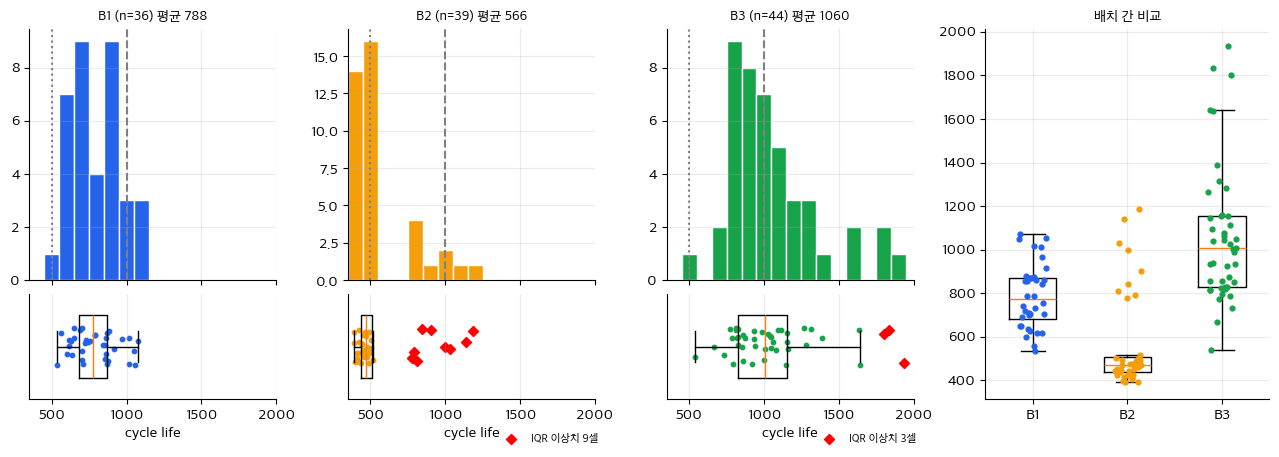

,n,mean,median,min,max,skew,>1000,<500,outliers,outliers_newstruct
batch,,,,,,,,,,
B1,36,788,772.5,534.0,1074.0,0.29,5 (14%),0 (0%),0,0
B2,39,566,472.0,392.0,1186.0,1.57,3 (8%),28 (72%),9,9
B3,44,1060,1005.5,541.0,1935.0,1.21,23 (52%),0 (0%),3,3


전체: >1000 31 셀 / <500 28 셀

[가장 짧은 셀 — 왜 짧은가]


,batch,cycle_life,policy,avg_c,newstruct
cell,,,,,
B2c19,B2,392.0,6C(60%)-3C,5.2500,0
B2c6,B2,393.0,3.6C(9%)-5C,4.8425,0
B2c15,B2,396.0,3.6C(9%)-5C,4.8425,0
B2c21,B2,408.0,6C(60%)-3C,5.2500,0
B2c30,B2,412.0,5.6C(26%)-4.5C,4.8575,0
B2c5,B2,416.0,3.6C(30%)-6C,5.1000,0


B1 최단:


,cycle_life,policy,avg_c
cell,,,
B1c20,534.0,5.4C(80%)-5.4C,5.4
B1c21,559.0,5.4C(80%)-5.4C,5.4


B2 기존 구조 {'count': 30.0, 'mean': 453.0, 'min': 392.0, 'max': 514.0} 
B2 newstructure {'count': 9.0, 'mean': 941.5555555555555, 'min': 777.0, 'max': 1186.0}


In [10]:
fig = plt.figure(figsize=(16, 4.8))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1.25], width_ratios=[1, 1, 1, 1.15], hspace=.08, wspace=.28)
for j, b in enumerate(BATCHES):
    g = V[V.batch == b]; cl = g.cycle_life
    a = fig.add_subplot(gs[0, j]); a.hist(cl, bins=np.arange(350, 2050, 100), color=COL[b], edgecolor='white')
    a.axvline(500, color='gray', ls=':'); a.axvline(1000, color='gray', ls='--'); a.set_xlim(350, 2000); a.tick_params(labelbottom=False)
    a.set_title(f'{b} (n={len(g)}) 평균 {cl.mean():.0f}', fontsize=10)
    bx = fig.add_subplot(gs[1, j], sharex=a); bx.boxplot(cl, vert=False, widths=.6, showfliers=False)
    q1_, q3_ = cl.quantile([.25, .75]); out = (cl < q1_ - 1.5 * (q3_ - q1_)) | (cl > q3_ + 1.5 * (q3_ - q1_))
    bx.scatter(cl[~out], 1 + rng.uniform(-.18, .18, (~out).sum()), s=10, color=COL[b])
    bx.scatter(cl[out], 1 + rng.uniform(-.18, .18, out.sum()), s=26, color='red', marker='D', label=f'IQR 이상치 {out.sum()}셀')
    if out.any(): bx.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.03, -0.28), frameon=False, borderaxespad=0)
    bx.set_yticks([]); bx.set_xlabel('cycle life')
ax3 = fig.add_subplot(gs[:, 3])
for i, b in enumerate(BATCHES):
    g = V[V.batch == b]; ax3.boxplot(g.cycle_life, positions=[i], widths=.5, showfliers=False)
    ax3.scatter(i + rng.uniform(-.15, .15, len(g)), g.cycle_life, s=12, color=COL[b], zorder=3)
ax3.set_xticks(range(3)); ax3.set_xticklabels(BATCHES); ax3.set_title('배치 간 비교', fontsize=10); plt.show()

q1 = []
for b, g in V.groupby('batch'):
    cl = g.cycle_life; lo, hi = cl.quantile([.25, .75]); iqr = hi - lo
    out = g[(cl > hi + 1.5 * iqr) | (cl < lo - 1.5 * iqr)]
    q1.append(dict(batch=b, n=len(g), mean=round(cl.mean()), median=cl.median(), min=cl.min(), max=cl.max(), skew=round(stats.skew(cl), 2),
                   **{'>1000': f'{(cl > 1000).sum()} ({(cl > 1000).mean():.0%})', '<500': f'{(cl < 500).sum()} ({(cl < 500).mean():.0%})'},
                   outliers=len(out), outliers_newstruct=int(out.newstruct.sum())))
display(pd.DataFrame(q1).set_index('batch'))
print('전체: >1000', (V.cycle_life > 1000).sum(), '셀 / <500', (V.cycle_life < 500).sum(), '셀')
print('\n[가장 짧은 셀 — 왜 짧은가]'); display(V.nsmallest(6, 'cycle_life')[['batch', 'cycle_life', 'policy', 'avg_c', 'newstruct']])
print('B1 최단:'); display(V[V.batch == 'B1'].nsmallest(2, 'cycle_life')[['cycle_life', 'policy', 'avg_c']])
b2 = V[V.batch == 'B2']; print('B2 기존 구조', b2[b2.newstruct == 0].cycle_life.agg(['count', 'mean', 'min', 'max']).to_dict(),
                              '\nB2 newstructure', b2[b2.newstruct == 1].cycle_life.agg(['count', 'mean', 'min', 'max']).to_dict())

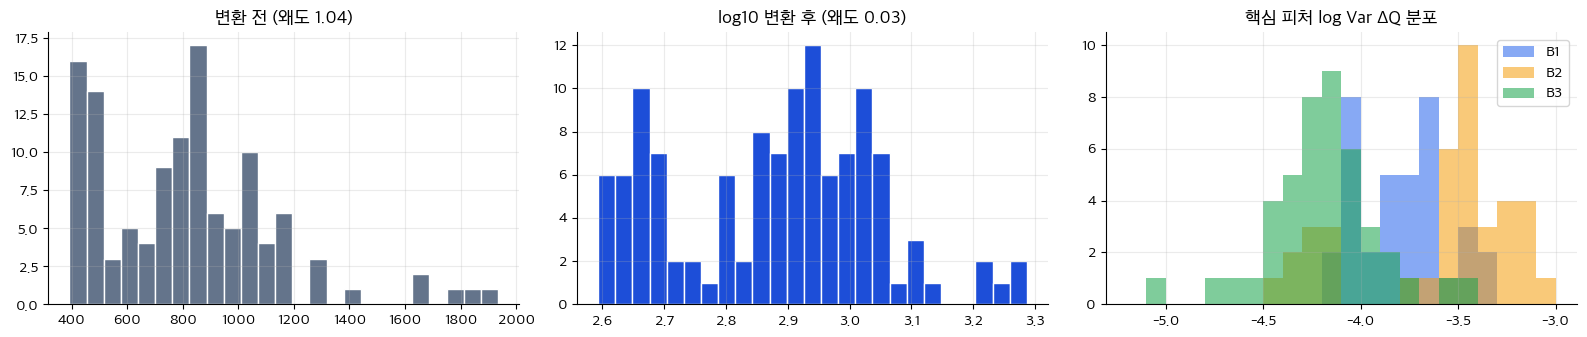

batch                   B1       B2       B3
cycle_life mean     788.42   565.74  1059.66
           std      148.70   222.20   313.87
           min      534.00   392.00   541.00
           median   772.50   472.00  1005.50
           max     1074.00  1186.00  1935.00
           skew       0.29     1.57     1.21
log_life   mean       2.89     2.73     3.01
           std        0.08     0.14     0.12
           min        2.73     2.59     2.73
           median     2.89     2.67     3.00
           max        3.03     3.07     3.29
           skew      -0.01     1.30     0.50
dq_var     mean      -3.79    -3.60    -4.19
           std        0.23     0.39     0.29
           min       -4.18    -4.45    -5.10
           median    -3.79    -3.49    -4.18
           max       -3.35    -3.09    -3.45
           skew       0.21    -0.91    -0.22

B2: B1 범위 밖 비율 44%, KS p = 8.2e-06
B3: B1 범위 밖 비율 48%, KS p = 9.4e-09


In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))
ax[0].hist(V.cycle_life, bins=25, color='#64748b', edgecolor='white'); ax[0].set_title(f'변환 전 (왜도 {stats.skew(V.cycle_life):.2f})')
ax[1].hist(V.log_life, bins=25, color='#1d4ed8', edgecolor='white'); ax[1].set_title(f'log10 변환 후 (왜도 {stats.skew(V.log_life):.2f})')
for b in BATCHES: ax[2].hist(V[V.batch == b].dq_var, bins=np.linspace(-5.2, -3, 23), alpha=.55, color=COL[b], label=b)
ax[2].set_title('핵심 피처 log Var ΔQ 분포'); ax[2].legend(); plt.tight_layout(); plt.show()

display(V.groupby('batch')[['cycle_life', 'log_life', 'dq_var']].agg(['mean', 'std', 'min', 'median', 'max', lambda x: stats.skew(x)]).rename(columns={'<lambda_0>': 'skew'}).round(2).T)
r1 = V[V.batch == 'B1'].dq_var
for b in ['B2', 'B3']:
    g = V[V.batch == b].dq_var
    print(f'{b}: B1 범위 밖 비율 {((g < r1.min()) | (g > r1.max())).mean():.0%}, KS p = {stats.ks_2samp(r1, g).pvalue:.1e}')

**③ 결과 · 해석**
- 평균 B1 788 · B2 566 · B3 1,060 (392~1,935). 장수명(>1,000) 26%(31셀), 단수명(<500) 24%(28셀, **전부 B2**).
- 이상치: B2 9셀 **전부 newstructure**, B3 3셀(1,801~1,935). 최단 셀(B2 392~425)은 기존 구조 + 고속 프로파일, B1 최단 c20·c21(534·559)은 5.4C를 80%까지 유지.
- log 변환으로 왜도 1.04 → 0.03 (B2는 두 하위집단 혼재로 1.30). log Var ΔQ는 B2 44% · B3 48%가 B1 범위 밖, KS p < 1e-5.

**④ 시사점** target = log10(cycle_life). B2 39셀 중 30셀이 B1 최솟값(534) 미만 → **외삽 가능한 모델**. 550 기준 분류는 B1이 35:1(섹션 4).

> “B2의 이상치는 측정 오류가 아니라 셀 구조가 다른 하위집단 — 충전방식보다 입고 셀(로트) 선별이 수명 편차를 더 크게 만든다”

## Q2. 열화 곡선 — 방전 용량은 어떻게 감소하는가?
**① 목적** 열화가 일정한지/가속되는지 알아야 “초기 100 cycle의 용량만으로 수명을 맞출 수 있는지” 판단할 수 있다.

**② 무엇을 했나**
- **[사이클별 Qd 추이]** 119셀 QD를 배치별·수명 색상으로 시각화 (정제 후)
- **[일정 vs 가속]** cycle 2→100 용량 변화, 초기 기울기–수명 상관, knee 전/후 기울기 비
- **[Knee point]** 셀마다 두 직선 piecewise 회귀로 기울기 변화점 탐색

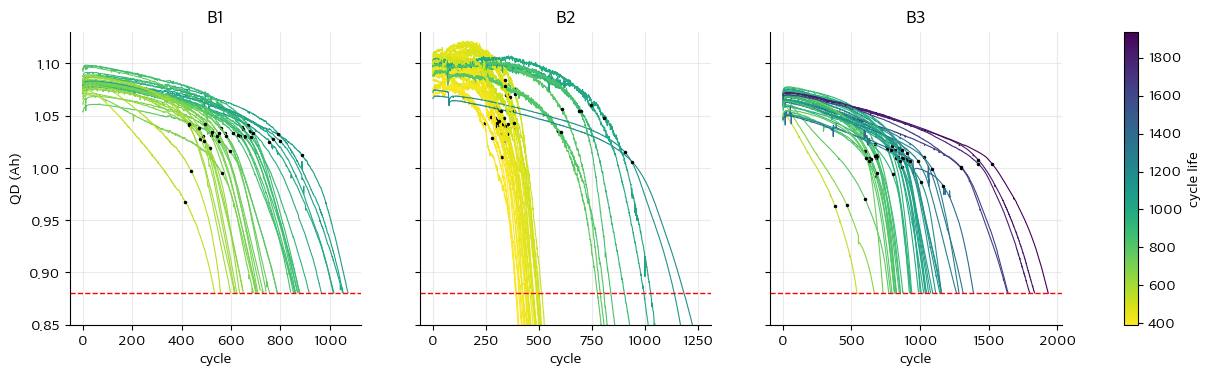

QD(100) > QD(2) 셀 비율: {'B1': 0.89, 'B2': 0.64, 'B3': 0.84}
초기 기울기(2~100)–log수명 ρ: 전체 -0.21 {'B1': np.float64(0.47), 'B2': np.float64(-0.25), 'B3': np.float64(0.09)}


In [12]:
norm = mc.Normalize(V.cycle_life.min(), V.cycle_life.max()); cmap = cm.viridis_r
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)
for a, b in zip(ax, BATCHES):
    for n in V[V.batch == b].index:
        cyc, q = clean_qd(byname[n]); a.plot(cyc, q, color=cmap(norm(V.loc[n, 'cycle_life'])), lw=.8)
        a.plot(V.loc[n, 'knee'], np.interp(V.loc[n, 'knee'], cyc, q), 'k.', ms=3)
    a.axhline(EOL, color='red', ls='--', lw=1); a.set_title(b); a.set_xlabel('cycle'); a.set_ylim(.85, 1.13)
ax[0].set_ylabel('QD (Ah)'); fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='cycle life'); plt.show()

print('QD(100) > QD(2) 셀 비율:', V.groupby('batch').apply(lambda g: (g.qd_diff_100_2 > 0).mean()).round(2).to_dict())
print('초기 기울기(2~100)–log수명 ρ: 전체', round(stats.spearmanr(V.qd_slope_2_100, V.log_life)[0], 2),
      {b: round(stats.spearmanr(g.qd_slope_2_100, g.log_life)[0], 2) for b, g in V.groupby('batch')})

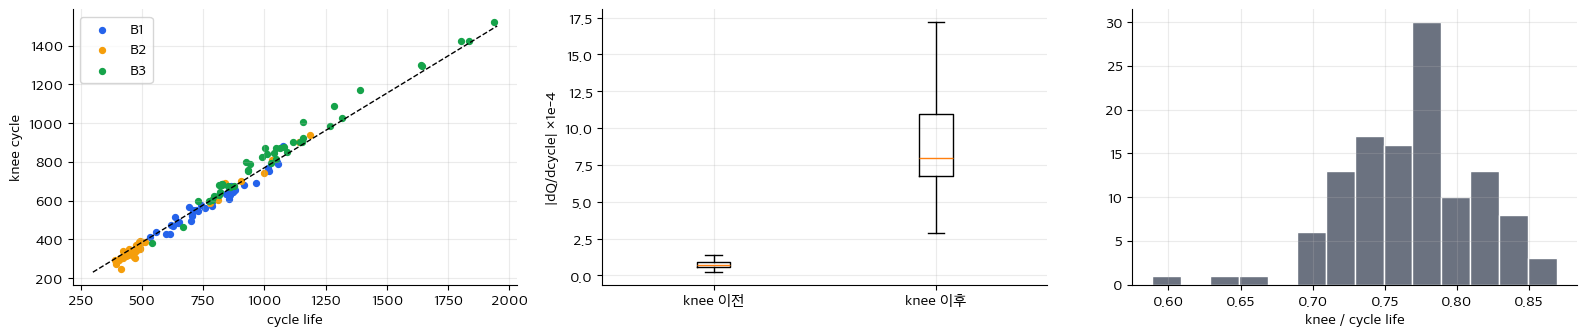

knee/수명 중앙값 0.77 (범위 0.59~0.87)
knee–수명 ρ 0.988 {'B1': np.float64(0.98), 'B2': np.float64(0.94), 'B3': np.float64(0.98)}
knee 이후 가속 배율 중앙값 10.4배, 모든 셀 1.5배 초과: True
가장 이른 knee 245.0 / 최단 수명 셀의 knee 295.0


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))
for b in BATCHES: g = V[V.batch == b]; ax[0].scatter(g.cycle_life, g.knee, s=18, color=COL[b], label=b)
ax[0].plot([300, 1950], [231, 1502], 'k--', lw=1); ax[0].legend(); ax[0].set_xlabel('cycle life'); ax[0].set_ylabel('knee cycle')
ax[1].boxplot([V.s1.abs(), V.s2.abs()], labels=['knee 이전', 'knee 이후'], showfliers=False); ax[1].set_ylabel('|dQ/dcycle| ×1e-4')
ax[2].hist(V.knee_frac, bins=14, color='#6b7280', edgecolor='white'); ax[2].set_xlabel('knee / cycle life'); plt.tight_layout(); plt.show()

print(f'knee/수명 중앙값 {V.knee_frac.median():.2f} (범위 {V.knee_frac.min():.2f}~{V.knee_frac.max():.2f})')
print('knee–수명 ρ', round(stats.spearmanr(V.knee, V.cycle_life)[0], 3), {b: round(stats.spearmanr(g.knee, g.cycle_life)[0], 2) for b, g in V.groupby('batch')})
print(f'knee 이후 가속 배율 중앙값 {V.ratio.median():.1f}배, 모든 셀 1.5배 초과: {(V.ratio > 1.5).all()}')
print('가장 이른 knee', V.knee.min(), '/ 최단 수명 셀의 knee', V.loc[V.cycle_life.idxmin(), 'knee'])

In [14]:
# 수명 구간별 열화 속도 · knee 시점 (열화 속도 단위: ×1e-4 Ah/cycle)
V['수명 구간'] = np.where(V.cycle_life < 500, '단수명(<500)', np.where(V.cycle_life > 1000, '장수명(>1000)', '중간'))
g = V.groupby('수명 구간').agg(셀수=('cycle_life', 'size'), 수명_중앙값=('cycle_life', 'median'), knee_중앙값=('knee', 'median'), knee_수명비율=('knee_frac', 'median'),
                            knee_이전_열화속도=('s1', lambda x: x.abs().median()), knee_이후_열화속도=('s2', lambda x: x.abs().median()))
display(g.round(2))
print('knee 이후 열화 속도–수명 Spearman ρ', round(stats.spearmanr(V.s2.abs(), V.cycle_life)[0], 2))
r = V.qd_100 / V.qd_2
print(f'초기 100 cycle 용량 변화: QD(100)/QD(2) 중앙값 {r.median():.3f} · 최대 변화 {100 * (r - 1).abs().max():.1f}%')

,셀수,수명_중앙값,knee_중앙값,knee_수명비율,knee_이전_열화속도,knee_이후_열화속도
수명 구간,,,,,,
단수명(<500),28,449.5,332.5,0.73,1.33,13.67
장수명(>1000),31,1115.0,905.0,0.79,0.57,5.81
중간,60,802.5,610.0,0.77,0.77,7.96


knee 이후 열화 속도–수명 Spearman ρ -0.83
초기 100 cycle 용량 변화: QD(100)/QD(2) 중앙값 1.002 · 최대 변화 2.1%


**③ 결과 · 해석**
- 모든 셀이 완만한 감소 → 급락(knee)형. 초기 100 cycle엔 오히려 용량 증가(QD(100) > QD(2): B1 89% · B2 64% · B3 84%). 초기 기울기–수명 ρ −0.21 (배치별 부호 흔들림).
- knee = 수명의 **77%**(59~87%), knee–수명 ρ 0.99. knee 이후 열화 **10.4배** 가속. 가장 이른 knee도 245 cycle.

**④ 시사점** 용량 곡선 자체는 약한 신호, 선형 외삽 불가. knee는 100 cycle에 관측 불가 → 피처로 쓰면 누수 → **초기에 보이는 대리 신호(ΔQ) 필요**.

> “초기 100 cycle 동안 용량은 거의 그대로 — 운영 중 용량만 모니터링해서는 교체 시점을 미리 알 수 없다”

## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?
**① 목적** 용량 총량에서 안 보이던 차이가 방전 곡선의 **형태**에는 나타나는지 확인하고, 모델 입력이 될 통계값으로 요약한다.

**② 무엇을 했나**
- **[cycle 100 − cycle 10]** `Qdlin`(2.0~3.5V, 1,000포인트) 차이 계산
- **[장/단수명 ΔQ 형태 비교]** 수명 색상으로 겹쳐 그림 + 최단·최장 셀 비교
- **[통계값 피처 추출]** Var·Min·Mean·Skew·Kurt (log10|·|) → 배치별 Spearman, 셀 구조별 직선 잔차

### ΔQ(V)란 무엇인가
- **방전 곡선**: 방전하면 전압이 3.5V → 2.0V로 떨어지는 동안 용량이 빠져나온다. LFP 셀은 2.9~3.15V 평탄 구간에서 용량 대부분이 나온다.
- **ΔQ(V) = Q(cycle 100) − Q(cycle 10)**: 두 방전 곡선을 전압마다 뺀 값. 음수 = 그 전압까지 나온 용량이 100번째에 그만큼 줄었다는 뜻.
- **빨강(B1c20, 수명 534)은 골이 깊고(−0.063Ah), 파랑(B1c5, 수명 1,074)은 얕다(−0.025Ah).**
- **용량 총량은 두 사이클이 비슷해도 전압별 차이는 이미 벌어져 있어, 100 cycle 시점에 단수명 셀을 알아볼 수 있다. 이 골이 얼마나 깊고 넓은지를 숫자 하나로 요약한 것이 핵심 피처 log Var ΔQ.**
- **노이즈**: 평탄 구간에선 전압 0.01V 변화에 용량 약 0.026Ah가 나와, 전압 측정 오차 1mV가 용량 차이 약 0.003Ah로 부풀려진다 → 평탄 구간에만 지글거림.

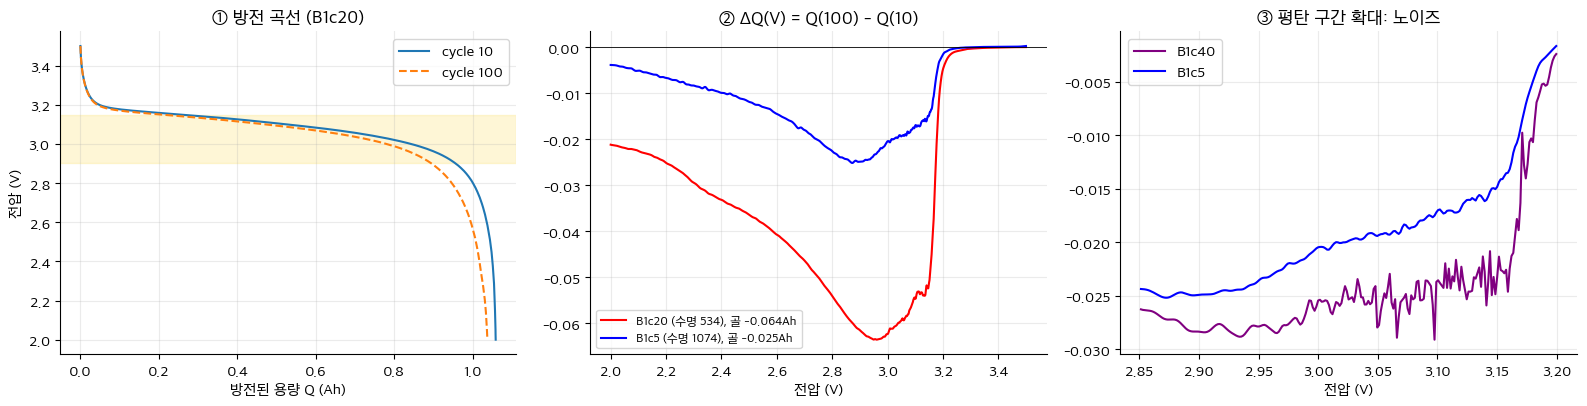

평탄 구간에서 전압 0.01V당 용량 변화 ≈ 0.026 Ah


In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
c = byname['B1c20']
ax[0].plot(c['Qdlin'][9], vdlin, label='cycle 10'); ax[0].plot(c['Qdlin'][99], vdlin, '--', label='cycle 100')
ax[0].axhspan(2.9, 3.15, color='#fde68a', alpha=.35); ax[0].set_xlabel('방전된 용량 Q (Ah)'); ax[0].set_ylabel('전압 (V)'); ax[0].legend(); ax[0].set_title('① 방전 곡선 (B1c20)')
for n, col in [('B1c20', 'red'), ('B1c5', 'blue')]:
    ax[1].plot(vdlin, delta_q(byname[n]), color=col, label=f"{n} (수명 {int(byname[n]['cycle_life'])}), 골 {np.nanmin(delta_q(byname[n])):.3f}Ah")
ax[1].axhline(0, color='k', lw=.6); ax[1].set_xlabel('전압 (V)'); ax[1].legend(fontsize=9); ax[1].set_title('② ΔQ(V) = Q(100) - Q(10)')
m = (vdlin >= 2.85) & (vdlin <= 3.2)
for n, col in [('B1c40', 'purple'), ('B1c5', 'blue')]: ax[2].plot(vdlin[m], delta_q(byname[n])[m], color=col, label=n)
ax[2].legend(); ax[2].set_xlabel('전압 (V)'); ax[2].set_title('③ 평탄 구간 확대: 노이즈'); plt.tight_layout(); plt.show()
q = byname['B1c5']['Qdlin'][9].astype(float); mm = (vdlin >= 2.95) & (vdlin <= 3.1)
print('평탄 구간에서 전압 0.01V당 용량 변화 ≈', round(abs(np.polyfit(vdlin[mm], q[mm], 1)[0]) * 0.01, 3), 'Ah')

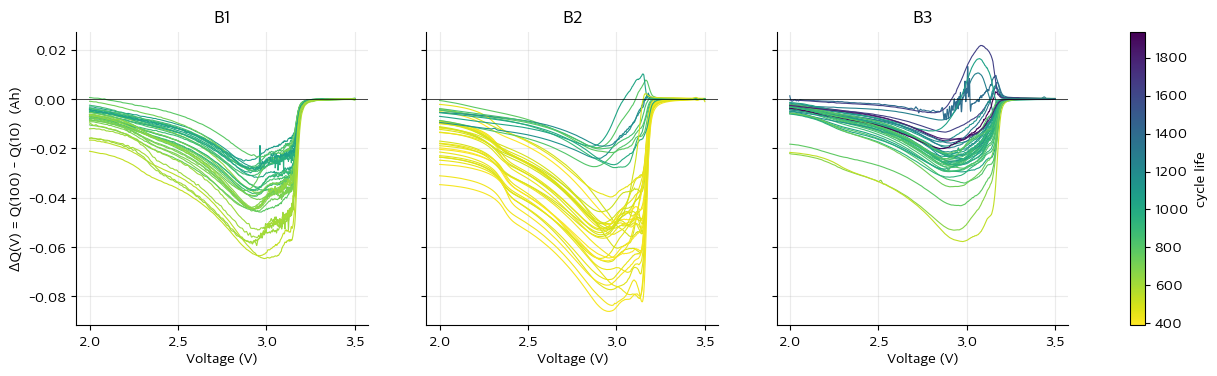

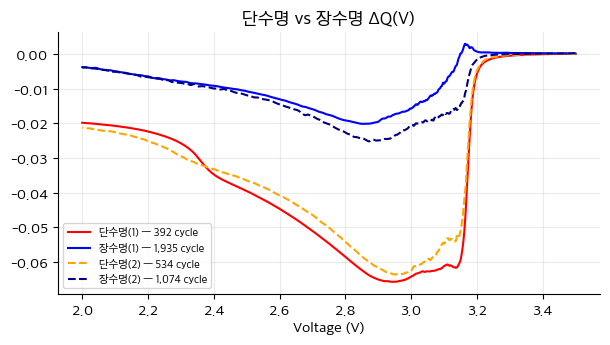

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)
for a, b in zip(ax, BATCHES):
    for n in V[V.batch == b].index: a.plot(vdlin, delta_q(byname[n]), color=cmap(norm(V.loc[n, 'cycle_life'])), lw=.8)
    a.set_title(b); a.set_xlabel('Voltage (V)'); a.axhline(0, color='k', lw=.5)
ax[0].set_ylabel('ΔQ(V) = Q(100) - Q(10)  (Ah)'); fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='cycle life'); plt.show()

plt.figure(figsize=(7, 3.4))
for n, col, ls, tag in [(V.cycle_life.idxmin(), 'red', '-', '단수명(1)'), (V.cycle_life.idxmax(), 'blue', '-', '장수명(1)'),
                        (V[V.batch == 'B1'].cycle_life.idxmin(), 'orange', '--', '단수명(2)'), (V[V.batch == 'B1'].cycle_life.idxmax(), 'navy', '--', '장수명(2)')]:
    plt.plot(vdlin, delta_q(byname[n]), color=col, ls=ls, label=f'{tag} — {int(V.loc[n, "cycle_life"]):,} cycle')
plt.legend(fontsize=8); plt.xlabel('Voltage (V)'); plt.title('단수명 vs 장수명 ΔQ(V)'); plt.show()

,전체,B1,B2,B3
dq_var,-0.89,-0.83,-0.71,-0.80
dq_min,-0.88,-0.79,-0.66,-0.78
dq_mean,-0.86,-0.76,-0.70,-0.76
dq_skew,0.22,0.28,0.22,-0.00
dq_kurt,-0.27,-0.24,-0.50,-0.02


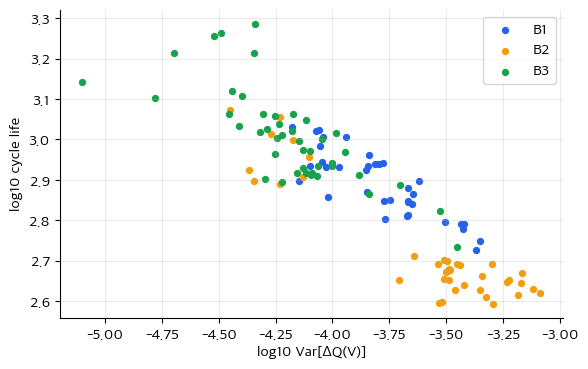

기존 구조 ρ -0.84 / newstructure ρ -0.7
기존 구조로 맞춘 직선이 newstructure를 설명하는 평균 배율: × 0.94


In [17]:
fs = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt']
tab = pd.DataFrame({'전체': [stats.spearmanr(V[f], V.log_life)[0] for f in fs],
                    **{b: [stats.spearmanr(g[f], g.log_life)[0] for f in fs] for b, g in V.groupby('batch')}}, index=fs).round(2)
display(tab)
fig, ax = plt.subplots(figsize=(6.5, 4))
for b in BATCHES: g = V[V.batch == b]; ax.scatter(g.dq_var, g.log_life, s=18, color=COL[b], label=b)
ax.set_xlabel('log10 Var[ΔQ(V)]'); ax.set_ylabel('log10 cycle life'); ax.legend(); plt.show()

o, nw = V[V.newstruct == 0], V[V.newstruct == 1]
m = np.polyfit(o.dq_var, o.log_life, 1)
print('기존 구조 ρ', round(stats.spearmanr(o.dq_var, o.log_life)[0], 2), '/ newstructure ρ', round(stats.spearmanr(nw.dq_var, nw.log_life)[0], 2))
print('기존 구조로 맞춘 직선이 newstructure를 설명하는 평균 배율: ×', round(10 ** (nw.log_life - np.polyval(m, nw.dq_var)).mean(), 2))

In [18]:
# ΔQ(V) 노이즈 점검: 평탄 구간(2.7~3.25V)에서 21점 이동 중앙값 대비 잔차 → 정상 셀 중앙값의 3배 초과 셀
win = (vdlin >= 2.7) & (vdlin <= 3.25); rows = []
for n in V.index:
    dq = delta_q(byname[n]); sm = pd.Series(dq).rolling(21, center=True, min_periods=1).median().values
    rows.append(dict(cell=n, batch=V.loc[n, 'batch'], noise=np.nanstd((dq - sm)[win]) * 1e3, var_raw=dq_feats(dq)['dq_var'], var_sm=dq_feats(sm)['dq_var'], log_life=V.loc[n, 'log_life']))
N = pd.DataFrame(rows).set_index('cell'); noisy = N[N.noise > N.noise.median() * 3]
print(f'노이즈가 큰 셀 {len(noisy)}개:', noisy.groupby('batch').size().to_dict())
print('스무딩 전후 log Var ΔQ 최대 차이', round((N.var_raw - N.var_sm).abs().max(), 3))
b = N[N.batch == 'B1']; print('B1 log수명 상관(원본 → 스무딩):', round(stats.spearmanr(b.var_raw, b.log_life)[0], 3), '→', round(stats.spearmanr(b.var_sm, b.log_life)[0], 3))

노이즈가 큰 셀 14개: {'B1': 10, 'B2': 2, 'B3': 2}
스무딩 전후 log Var ΔQ 최대 차이 0.061
B1 log수명 상관(원본 → 스무딩): -0.826 → -0.825


**③ 결과 · 해석**
- 모든 셀에서 2.7~3.1V 부근 음의 골. 단수명 −0.04~−0.09Ah로 깊고, 장수명 −0.02~−0.03Ah로 얕음. 세 배치 색 순서 일치.
- log Var: 전체 ρ **−0.89**, 배치별 −0.83 / −0.71 / −0.80. Min −0.88, Mean −0.86. Skew·Kurt는 배치마다 불안정.
- 기존 구조로 맞춘 직선이 newstructure 셀을 평균 ×0.94로 설명 → 셀 구조와 무관하게 같은 직선.

**④ 시사점** 핵심 피처 = log Var ΔQ. Min·Mean은 대체재(Q5 공선성). 양(+) 돌출 셀 → log|·| 변환 주의.

> “QD 총량은 같아도 곡선 모양은 이미 갈라져 있다 — 수명의 5~25% 시점(100 cycle)에 단수명 셀을 조기 선별할 근거”

## Q4. 충전 조건(C-rate)과 수명의 관계는?
**① 목적** 충전 조건이 수명을 설명한다면 바로 피처가 된다 — 배치가 바뀌어도 관계가 유지되는지 확인한다.

**② 무엇을 했나**
- **[충전방식별 평균 수명]** 배치×충전방식 그룹 평균 ± 표준편차
- **[고속 충전 셀]** 충전방식 문자열 파싱(1·2단계 C-rate, 전환 SOC, 평균 C-rate, 0→80% 소요 시간) → 전체 vs 배치 내 상관, 같은 충전방식의 구조별 비교
- **[충전 전류 패턴–열화 속도]** 평균 C-rate vs knee 전·후 열화 속도

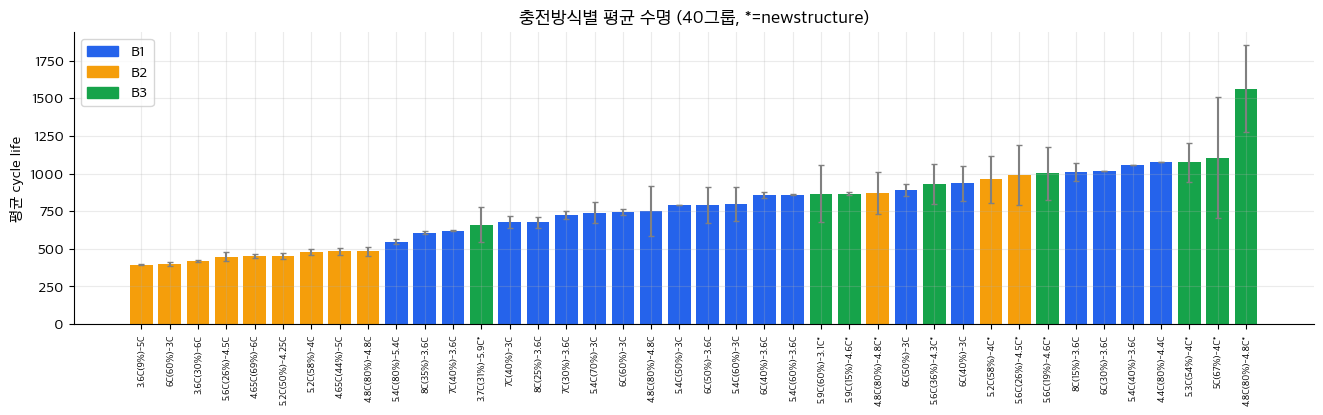

,batch,pol,life,sd,n
21,B2,3.6C(9%)-5C,394.5,2.121320,2
31,B2,6C(60%)-3C,400.0,11.313708,2
20,B2,3.6C(30%)-6C,421.0,7.071068,2


,batch,pol,life,sd,n
34,B3,5.3C(54%)-4C*,1074.375000,129.674248,8
39,B3,5C(67%)-4C*,1105.714286,402.911783,7
33,B3,4.8C(80%)-4.8C*,1564.166667,285.721834,6


In [19]:
V['pol'] = V.policy.str.replace('-newstructure', '*', regex=False)
pm = V.groupby(['batch', 'pol']).agg(life=('cycle_life', 'mean'), sd=('cycle_life', 'std'), n=('cycle_life', 'size')).reset_index().sort_values('life')
plt.figure(figsize=(16, 3.8)); x = np.arange(len(pm))
plt.bar(x, pm.life, yerr=pm.sd.fillna(0), color=[COL[b] for b in pm.batch], error_kw=dict(ecolor='gray', capsize=2))
plt.xticks(x, pm.pol, rotation=90, fontsize=7); plt.ylabel('평균 cycle life'); plt.title(f'충전방식별 평균 수명 ({len(pm)}그룹, *=newstructure)')
plt.legend(handles=[Patch(color=COL[b], label=b) for b in BATCHES]); plt.show()
display(pm.head(3)); display(pm.tail(3))

0→80% 충전 소요(분, 설계값): {'min': 8.9, '50%': 10.0, 'max': 12.0} | 실측 충전시간 중앙값 10.2
전체 상관: {'c1': np.float64(0.08), 'c2': np.float64(-0.12), 'avg_c': np.float64(-0.25), 'newstruct': np.float64(0.66)}
배치 내 평균 C-rate–수명 ρ: {'B1': np.float64(-0.78), 'B2': np.float64(-0.18), 'B3': np.float64(-0.52)}


newstruct,0,1
base,,
4.8C(80%)-4.8C,484.0,872.0
5.2C(58%)-4C,478.0,962.0
5.6C(26%)-4.5C,448.0,991.0


충전방식 수 {'B1': 20, 'B2': 9, 'B3': 8} | 공유: B1∩B2 2 B2∩B3 1 B1∩B3 1


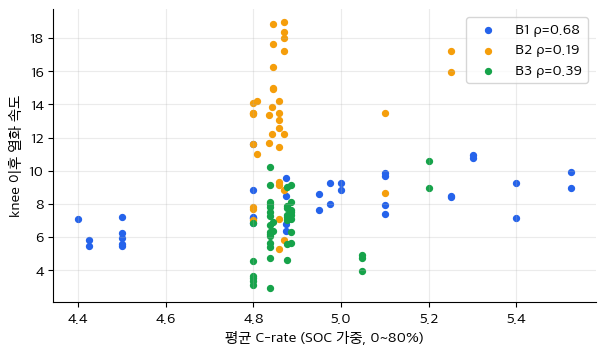

knee 이전 열화 속도–평균 C-rate ρ: {'B1': np.float64(0.77), 'B2': np.float64(-0.11), 'B3': np.float64(0.41)}


In [20]:
print('0→80% 충전 소요(분, 설계값):', V.t80_min.describe()[['min', '50%', 'max']].round(1).to_dict(), '| 실측 충전시간 중앙값', round(V.ct_mean.median(), 1))
print('전체 상관:', {k: round(stats.spearmanr(V[k], V.cycle_life)[0], 2) for k in ['c1', 'c2', 'avg_c', 'newstruct']})
print('배치 내 평균 C-rate–수명 ρ:', {b: round(stats.spearmanr(g.avg_c, g.cycle_life)[0], 2) for b, g in V.groupby('batch')})
same = V[V.batch == 'B2'].assign(base=lambda d: d.policy.str.replace('-newstructure', '', regex=False))
display(same[same.base.isin(['4.8C(80%)-4.8C', '5.2C(58%)-4C', '5.6C(26%)-4.5C'])].groupby(['base', 'newstruct']).cycle_life.mean().unstack().round(0))
P = {b: set(V[V.batch == b].pol.str.rstrip('*')) for b in BATCHES}
print('충전방식 수', {b: len(p) for b, p in P.items()}, '| 공유: B1∩B2', len(P['B1'] & P['B2']), 'B2∩B3', len(P['B2'] & P['B3']), 'B1∩B3', len(P['B1'] & P['B3']))

plt.figure(figsize=(7, 3.8))
for b in BATCHES:
    g = V[V.batch == b]; plt.scatter(g.avg_c, g.s2.abs(), s=18, color=COL[b], label=f'{b} ρ={stats.spearmanr(g.avg_c, g.s2.abs())[0]:.2f}')
plt.xlabel('평균 C-rate (SOC 가중, 0~80%)'); plt.ylabel('knee 이후 열화 속도'); plt.legend(); plt.show()
print('knee 이전 열화 속도–평균 C-rate ρ:', {b: round(stats.spearmanr(g.avg_c, g.s1.abs())[0], 2) for b, g in V.groupby('batch')})

**③ 결과 · 해석**
- 모든 충전방식의 0→80% 충전 ≈ 10분 → 충전시간 자체는 변별력 없음.
- 전체 C-rate–수명 상관 거의 없음(c1 0.08, 평균 C-rate −0.25), 배치 내 −0.78 / −0.18 / −0.52. newstructure ρ +0.66.
- 같은 충전방식(B2): 기존 구조 448~484 vs newstructure 872~991(약 2배). 같은 4.8C(80%)-4.8C가 484 → 1,564(3.2배).
- C-rate–열화 속도 ρ: knee 전 0.77 / −0.11 / 0.41, knee 후 0.68 / 0.19 / 0.39 → B1 안에서만 뚜렷.

**④ 시사점** 충전방식 집합이 배치마다 다름(B1·B2 공유 2개) → C-rate 입력 제외. newstructure는 B1에 0건 → 학습 불가. 같은 충전방식끼리 같은 fold(GroupKFold).

> “‘고속 충전 = 단명’은 같은 셀 구조 안에서만 성립 — 수명 차이는 충전방식보다 셀 구조에서 2배로 벌어진다”

## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?
**① 목적** 후보 피처의 관련성·안정성·중복을 확인해 피처 선정 기준을 세운다.

**② 무엇을 했나**
- **[상관 계수]** 초기 사이클 피처 vs log 수명, 전체 + 배치별 Spearman
- **[가장 강한 관계]** 순위와 배치 간 일관성
- **[멀티콜리니어리티]** VIF, |ρ| ≥ 0.8 쌍

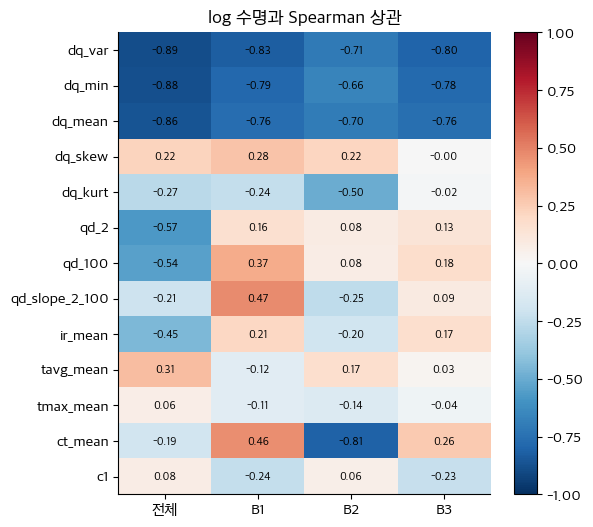

,전체,B1,B2,B3
dq_var,-0.89,-0.83,-0.71,-0.80
dq_min,-0.88,-0.79,-0.66,-0.78
dq_mean,-0.86,-0.76,-0.70,-0.76
qd_2,-0.57,0.16,0.08,0.13
qd_100,-0.54,0.37,0.08,0.18
ir_mean,-0.45,0.21,-0.20,0.17
tavg_mean,0.31,-0.12,0.17,0.03
dq_kurt,-0.27,-0.24,-0.50,-0.02
dq_skew,0.22,0.28,0.22,-0.00
qd_slope_2_100,-0.21,0.47,-0.25,0.09


VIF: {'dq_min': 83.2, 'dq_mean': 45.9, 'tavg_mean': 45.8, 'dq_var': 24.5, 'tmax_mean': 19.6, 'tmin_mean': 11.5, 'qd_2': 4.4, 'qc_mean': 4.4, 'ir_mean': 2.1, 'dq_kurt': 1.9, 'qd_slope_2_100': 1.7, 'dq_skew': 1.5, 'ct_mean': 1.4}
|r| > 0.8 쌍: [('dq_min', 'dq_mean', np.float64(0.98)), ('dq_var', 'dq_min', np.float64(0.97)), ('dq_var', 'dq_mean', np.float64(0.92)), ('tavg_mean', 'tmax_mean', np.float64(0.87)), ('tavg_mean', 'tmin_mean', np.float64(0.84)), ('qd_2', 'qc_mean', np.float64(0.81))]


In [21]:
FEATS = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'qd_2', 'qd_100', 'qd_slope_2_100', 'ir_mean', 'tavg_mean', 'tmax_mean', 'ct_mean', 'c1']
H = pd.DataFrame({'전체': V[FEATS + ['log_life']].corr('spearman')['log_life'].drop('log_life'),
                  **{b: g[FEATS + ['log_life']].corr('spearman')['log_life'].drop('log_life') for b, g in V.groupby('batch')}})
fig, ax = plt.subplots(figsize=(6, 6)); im = ax.imshow(H.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(H.columns); ax.set_yticks(range(len(FEATS))); ax.set_yticklabels(FEATS); ax.grid(False)
for i in range(len(FEATS)):
    for j in range(4): ax.text(j, i, f'{H.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im); plt.title('log 수명과 Spearman 상관'); plt.show()
display(H.sort_values('전체', key=abs, ascending=False).round(2))

G = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'qd_2', 'qd_slope_2_100', 'ir_mean', 'tavg_mean', 'tmax_mean', 'tmin_mean', 'ct_mean', 'qc_mean']
X = V[G].fillna(V[G].median()); X = (X - X.mean()) / X.std()
vif = pd.Series(np.diag(np.linalg.inv(np.corrcoef(X.T.values))), G).sort_values(ascending=False).round(1)
print('VIF:', vif.to_dict())
cmx = X.corr().abs(); print('|r| > 0.8 쌍:', sorted([(a, b, round(cmx.loc[a, b], 2)) for i, a in enumerate(G) for b in G[i+1:] if cmx.loc[a, b] > .8], key=lambda t: -t[2]))

**③ 결과 · 해석**
- ΔQ: Var −0.89, Min −0.88, Mean −0.86 (배치별 −0.66~−0.83).
- QD(2) −0.57, IR −0.45, T avg +0.31 등 풀링 상관은 배치 내 |ρ| ≤ 0.37로 약해지고 부호가 바뀜 → 배치·셀 구조 효과로 생긴 겉보기 상관.
- VIF: ΔQ Min 83 · Mean 46 · Var 24, T avg 46 · T max 20 · T min 11.

**④ 시사점** ΔQ는 대표 1개(log Var)만, 나머지는 대체재. IR·온도는 일관성 없음. 판정은 학습 배치(B1) 기준으로(섹션 5).

> “풀링 상관 대부분은 배치·셀 구조가 만든 겉보기 상관 — 모든 배치에서 일관된 신호는 ΔQ(V)뿐”

## 4. 종합 — 배치 간 분포 이동과 회귀 선택
**① 목적** 학습(B1)에서 배운 관계가 B2·B3에서도 통하는지, 분류(550 cycle 기준)로 풀 수 있는지 확인한다.

**② 무엇을 했나** 배치별 550 기준 클래스 비율·다수결 정확도 계산, log Var ΔQ 단일 피처 예비 baseline(B1 학습 → B2·B3 MAPE).

,B1,B2,B3
550 이상,35,9,43
550 미만,1,30,1
다수결 정확도,97%,77%,98%
수명 범위,534~1074,392~1186,541~1935
newstructure,0,9,44


B2 중 B1 최솟값 미만: 30 / 39 | B3 중 B1 최댓값 초과: 16 / 44
예비 baseline MAPE B1: 8.2%
예비 baseline MAPE B2: 28.6%
예비 baseline MAPE B3: 12.8%


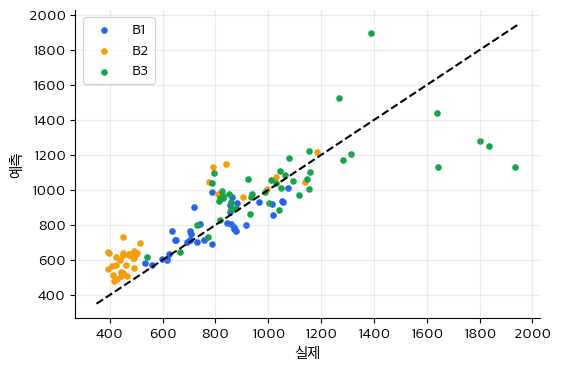

In [22]:
mape = lambda y, p: 100 * np.mean(np.abs(y - p) / y)
b1, b2, b3 = [V[V.batch == b] for b in BATCHES]
display(pd.DataFrame({b: {'550 이상': int((g.cycle_life >= 550).sum()), '550 미만': int((g.cycle_life < 550).sum()),
                          '다수결 정확도': f'{max((g.cycle_life >= 550).mean(), (g.cycle_life < 550).mean()):.0%}',
                          '수명 범위': f'{g.cycle_life.min():.0f}~{g.cycle_life.max():.0f}', 'newstructure': int(g.newstruct.sum())}
                      for b, g in zip(BATCHES, [b1, b2, b3])}))
print('B2 중 B1 최솟값 미만:', (b2.cycle_life < b1.cycle_life.min()).sum(), '/', len(b2), '| B3 중 B1 최댓값 초과:', (b3.cycle_life > b1.cycle_life.max()).sum(), '/', len(b3))

lr = LinearRegression().fit(b1[['dq_var']], b1.log_life)
plt.figure(figsize=(6, 4))
for b, g in zip(BATCHES, [b1, b2, b3]):
    p = 10 ** lr.predict(g[['dq_var']]); print(f'예비 baseline MAPE {b}: {mape(g.cycle_life, p):.1f}%'); plt.scatter(g.cycle_life, p, s=14, color=COL[b], label=b)
plt.plot([350, 1950], [350, 1950], 'k--'); plt.xlabel('실제'); plt.ylabel('예측'); plt.legend(); plt.show()

**③ 결과** 550 기준: B1 35:1, B2 9:30, B3 43:1 → B1 음성 1셀이라 분류 학습·검증 불가, B2는 다수결만으로 77%. 예비 baseline MAPE: B1 8.2%(학습) · **B2 28.6%** · B3 12.8% (원논문 목표 9.1%). B2는 500~650 근처에서 막혀 과대예측.
**④ 시사점** **Regression 선택**. B2 성능의 핵심은 학습 범위 밖 외삽 → 모델 선택 기준.

## 5. Feature Engineering — 22개 후보 → 핵심 1 + 보조 3
판정은 **학습 배치(B1)만**으로 한다(테스트 Target 누수 방지). B2/B3는 “경고” 표시에만 사용.

| 단계 | 기준 |
|---|---|
| S1 사용 가능성 | 첫 100 cycle에서 계산되는 값만 (knee 등 사후 정보 제외) |
| S2 측정값 vs 설계 조건 | 충전방식 파싱 변수(c1, c2, 전환 SOC, 평균 C-rate, newstructure) 제외 |
| S3 관련성 | B1 bootstrap 2,000회 95% CI가 0을 포함하면 제외 |
| S4 중복 제거 | B1에서 \|ρ\| ≥ 0.9 쌍은 수명 상관이 큰 것만 |
| S5 배치 간 부호 (참고) | B2/B3에서 부호가 다르면 “보조(경고)” |

In [23]:
CAND = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'qd_slope_2_100', 'qd_diff_100_2', 'qd_2', 'qd_100', 'qd_max_2_100',
        'ir_mean', 'ir_100_2', 'tavg_mean', 'tmax_mean', 'tmin_mean', 'ct_mean', 'qc_mean']   # 측정 신호 17개
LABELS = ['c1', 'c2', 'soc_sw', 'avg_c', 'newstruct']                                           # 설계 조건 5개 → S2 제외
b1 = V[V.batch == 'B1']; rng = np.random.default_rng(0)   # 재현을 위해 시드 고정

def boot_ci(x, y, B=2000):
    ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]; n = len(x)
    return np.nanpercentile([stats.spearmanr(x[i], y[i])[0] for i in (rng.integers(0, n, n) for _ in range(B))], [2.5, 97.5])

S = []
for f in CAND:
    x, y = b1[f].values.astype(float), b1.log_life.values; lo, hi = boot_ci(x, y)
    S.append(dict(feat=f, b1_rho=stats.spearmanr(x, y, nan_policy='omit')[0], ci_lo=lo, ci_hi=hi,
                  rho_B2=stats.spearmanr(V[V.batch == 'B2'][f], V[V.batch == 'B2'].log_life, nan_policy='omit')[0],
                  rho_B3=stats.spearmanr(V[V.batch == 'B3'][f], V[V.batch == 'B3'].log_life, nan_policy='omit')[0]))
S = pd.DataFrame(S).set_index('feat')
S['decision'] = np.where((S.ci_lo > 0) | (S.ci_hi < 0), '통과', '제외(S3)')
C = b1[CAND].corr('spearman').abs(); keep = []
for f in S[S.decision == '통과'].sort_values('b1_rho', key=abs, ascending=False).index:
    dup = [k for k in keep if C.loc[f, k] >= .9]
    if dup: S.loc[f, 'decision'] = f'대체재(S4: {dup[0]})'
    else: keep.append(f)
for f in keep:
    if np.sign(S.loc[f, 'rho_B2']) != np.sign(S.loc[f, 'b1_rho']) or np.sign(S.loc[f, 'rho_B3']) != np.sign(S.loc[f, 'b1_rho']):
        S.loc[f, 'decision'] = '보조(경고, S5)'
display(S.round(2).sort_values('b1_rho'))
print('S2 제외(설계 조건):', LABELS, '| B1 평균 C-rate ρ =', round(stats.spearmanr(b1.avg_c, b1.log_life)[0], 2))

,b1_rho,ci_lo,ci_hi,rho_B2,rho_B3,decision
feat,,,,,,
dq_var,-0.83,-0.92,-0.66,-0.71,-0.80,통과
dq_min,-0.79,-0.90,-0.60,-0.66,-0.78,대체재(S4: dq_var)
dq_mean,-0.76,-0.90,-0.55,-0.70,-0.76,대체재(S4: dq_var)
dq_kurt,-0.24,-0.58,0.13,-0.50,-0.02,제외(S3)
ir_100_2,-0.22,-0.60,0.18,0.26,-0.23,제외(S3)
tavg_mean,-0.12,-0.42,0.22,0.17,0.03,제외(S3)
tmax_mean,-0.11,-0.42,0.23,-0.14,-0.04,제외(S3)
tmin_mean,0.06,-0.30,0.39,0.34,0.13,제외(S3)
qd_2,0.16,-0.16,0.45,0.08,0.13,제외(S3)


S2 제외(설계 조건): ['c1', 'c2', 'soc_sw', 'avg_c', 'newstruct'] | B1 평균 C-rate ρ = -0.78


In [24]:
print('B1에서 ΔQ 통계끼리 |Spearman|: Var–Min %.2f · Var–Mean %.2f' % (C.loc['dq_var', 'dq_min'], C.loc['dq_var', 'dq_mean']))

B1에서 ΔQ 통계끼리 |Spearman|: Var–Min 0.99 · Var–Mean 0.97


**결과** 핵심: **log Var ΔQ** · 보조: QD(cycle 100), QD 기울기(경고), 충전시간(경고) · 대체재: log |Min ΔQ|, log |Mean ΔQ|
(제외: Skew·Kurt, IR, 온도, QC, QD(2) 등 S3 10개 + 충전방식 변수 5개)

## 6. 모델 설계 전략 요약
| 결정 | 내용 | EDA 근거 |
|---|---|---|
| Regression vs Classification (택1) | **Regression** (초기 100 cycle → 총 수명) | 섹션 4: 분류는 B1 35:1 |
| Target | **Target Data = cycle_life** (EOL 80% SOH, 0.88Ah까지 사이클 수). 모델은 **y = log10(cycle_life)** 예측. MAPE는 10^ŷ로 역변환 | Q1 왜도 1.04→0.03, Q3 log–log 직선 |
| 데이터 처리 | EOL 미도달·Target 값 없는 셀 제외 → cycle 1 더미 제거 → QD 2단계 스파이크 보간 → ΔQ(100−10) → 스케일러는 train fold에서만 fit | 섹션 1–2 |
| 피처 (X값) | 초기 100 cycle 데이터로 계산한 피처만: 핵심 log Var ΔQ(cycle 100−10) / 보조 QD(cycle 100)·QD 기울기(2~100)·충전시간(2~100) / 대체재 2개 | 도메인 정보에서 “초기 100사이클만으로 전체 수명 예측 가능”이라고 하니 100사이클로 예측 시도. 피처 선정은 섹션 5 |
| 검증 | Train = B1 GroupKFold(같은 충전방식끼리 묶음) CV · Valid = B1 같은 충전방식끼리 묶은 hold-out · Test = B2 (추가 B3) | Q4: 같은 충전방식끼리 나뉘면 누수 |

**확인한 데이터 특성 → 모델링 전략 → 채택한 후보 모델**
| 데이터 특성 | 근거 | 모델링 전략 → 채택 |
|---|---|---|
| 학습 셀이 36개뿐 | B1 36셀 | 단순·정규화 모델 우선, 딥러닝 제외 → ① OLS, ② Elastic Net |
| B1에 단수명 셀이 1개뿐 | B1의 550 미만 1셀, B2는 39셀 중 30셀이 B1보다 짧음 | 짧은 수명도 직선으로 예측하는 선형 모델 주력 → ② Elastic Net, ③ PLS (트리는 비교군) |
| 핵심 피처와 수명이 직선 관계 | B1 ρ −0.83, 곡선을 넣어도 개선 없음 | 직선 모델로 충분 → ① OLS 기준선, ④ SVR/GPR로 재확인 |
| 피처끼리 정보가 겹침 | ΔQ 통계끼리 상관 0.92~0.98 | 규제 또는 묶기 → ② Elastic Net, ③ PLS |
| 배치마다 방향이 바뀌는 피처 | 충전시간, QD 기울기 | 보조로만 쓰고 조합 효과 확인 → ⑤ RF/GBM (비교군) |
| 같은 충전방식끼리 수명이 비슷 | 충전방식 하나에 1~2셀씩 실험 | 같은 충전방식끼리 묶어 검증 데이터 분할 → 모든 모델 |
| 구조가 다른 셀이 섞임 | B2 newstructure 9셀, B1엔 없음 | B2 오차를 구조별로 보고 → 모든 모델 |

**후보 모델 (모두 회귀)**
| 모델 | 역할 | 이유 |
|---|---|---|
| ① OLS (log Var ΔQ 1개) | 기준선 | 원논문 방식, 다른 모델이 이걸 넘는지 비교 |
| ② Elastic Net | 주력 | 셀이 적고 피처가 겹쳐 규제 필요, 짧은 수명도 직선으로 예측 |
| ③ PLS | 주력 | 겹치는 피처를 몇 개 요인으로 묶음 (M3) |
| ④ SVR / GPR | 확인용 | 곡선 모델로 직선이면 충분한지 재확인 |
| ⑤ RF / GBM | 비교군 | 피처 조합 효과 확인, 짧은 수명엔 약할 것 |

**왜 딥러닝이 아닌가** 셀 36개 vs 신경망 파라미터 수천 개 이상 → 과적합.
**피처 세트(ablation)** M1 = 핵심피처, M2 = 보조피처 + M1, M3 = 대체재피처 + M1 + M2